In [ ]:
from datasets import load_from_disk

dataset = load_from_disk("datasets/mscoco_15k/mscoco_15k_train/")

Dataset({
    features: ['image', 'text'],
    num_rows: 9988
})

### 构建“图片→共同语义M→文本”因果链

In [3]:
from tqdm.auto import tqdm
from models.clip import evaluate_clip
from common import make_train_valid_dfs, build_loaders
from models.clip.evaluate import get_image_embeddings, find_matches

from models.clip.config import CLIPConfig
from transformers import DistilBertTokenizer
import torch
from torch import nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt

from matplotlib import pyplot as plt
from models.clip.config import CLIPConfig
from models.clip.model import CLIPModel

import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from causalchain.frontdoor_concrete_example import FrontDoorCausalChain, run_concrete_example, visualize_causal_chain
from common.dataset import get_transforms, BaseDataset

ImportError: attempted relative import beyond top-level package

from transformers import ViltProcessor, ViltForQuestionAnswering

processor = ViltProcessor.from_pretrained("../models/vilt/")
model = ViltForQuestionAnswering.from_pretrained("../models/vilt/")

In [2]:
config = CLIPConfig()
tokenizer = DistilBertTokenizer.from_pretrained(config.text_model_path)
model = CLIPModel().to(config.device)
model.load_state_dict(torch.load("./best_1.pt", map_location=config.device))
model.eval()
print_flag = True

single_dataset = BaseDataset(
    image_filenames=['2284231661.jpg'],
    captions=['Four men are sitting in red chairs'],
    ids=[0],
    tokenizer=tokenizer,
    transforms=get_transforms(mode="valid")
)

single_dataloader = torch.utils.data.DataLoader(
    single_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

for batch in single_dataloader:
    print(batch['image'].shape)  # (1, 3, H, W)
    print(batch['caption'])
    break

image_features = model.image_encoder(batch['image'].to(config.device))
image_embeddings = model.image_projection(image_features)
print(image_features)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5979.22it/s]
DistilBertModel LOAD REPORT from: /home/lthpc/Desktop/fuxpData/code/causality/models/distilbertdistilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 3, 224, 224])
['Four men are sitting in red chairs']
tensor([[0.0350, 0.0061, 0.0158,  ..., 0.0000, 0.0684, 0.0000]],
       grad_fn=<ViewBackward0>)


/home/lthpc/Desktop/fuxpData/code/causality/baseline/common/dataset.py:69: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(size, size, always_apply=True),
/home/lthpc/Desktop/fuxpData/code/causality/baseline/common/dataset.py:70: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0, always_apply=True),


In [3]:
batch_size = 1
image_feat_dim = 2048
text_feat_dim = 768

causal_chain = FrontDoorCausalChain(
    shared_dim=256,
    image_feat_dim=image_feat_dim,
    text_feat_dim=text_feat_dim
)

In [5]:
query = 'Four men are sitting in red chairs'
config = CLIPConfig()
tokenizer = DistilBertTokenizer.from_pretrained(config.text_model_path)
encoded_query = tokenizer([query])

batch = {
    key: torch.tensor(values).to(config.device)
    for key, values in encoded_query.items()
}

# 编码文本查询
with torch.no_grad():
    text_features = model.text_encoder(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )
    text_embeddings = model.text_projection(text_features)

print(text_features.shape)

torch.Size([1, 768])


In [6]:
features = causal_chain.encode_to_shared_private(image_features, text_features)

In [7]:
img_shared = features['image_shared']
img_private = features['image_private']
txt_shared = features['text_shared']
txt_private = features['text_private']

In [8]:
print("图像特征分解:")
print(f"  - Image Shared: {img_shared.shape}")
print(f"    均值: {img_shared.mean().item():.4f}")
print(f"    标准差: {img_shared.std().item():.4f}")
print(f"    前5维: {img_shared[0, :5].detach().numpy()}")

print(f"\n  - Image Private: {img_private.shape}")
print(f"    均值: {img_private.mean().item():.4f}")
print(f"    标准差: {img_private.std().item():.4f}")

print("\n文本特征分解:")
print(f"  - Text Shared: {txt_shared.shape}")
print(f"    均值: {txt_shared.mean().item():.4f}")
print(f"    标准差: {txt_shared.std().item():.4f}")
print(f"    前5维: {txt_shared[0, :5].detach().numpy()}")

print(f"\n  - Text Private: {txt_private.shape}")
print(f"    均值: {txt_private.mean().item():.4f}")
print(f"    标准差: {txt_private.std().item():.4f}")

图像特征分解:
  - Image Shared: torch.Size([1, 256])
    均值: -0.0047
    标准差: 0.0662
    前5维: [ 0.09678546 -0.0205711  -0.05063189 -0.05627897 -0.01490449]

  - Image Private: torch.Size([1, 614])
    均值: 0.0038
    标准差: 0.0643

文本特征分解:
  - Text Shared: torch.Size([1, 256])
    均值: -0.0397
    标准差: 0.2797
    前5维: [ 0.30044383  0.6889267  -0.38233644 -0.1182381   0.1629593 ]

  - Text Private: torch.Size([1, 230])
    均值: 0.0158
    标准差: 0.2882


In [9]:
shared_semantic = causal_chain.compute_shared_semantic(img_shared, txt_shared)

In [10]:
print(f"共享语义 M shape: {shared_semantic.shape}")
print(f"  - 包含: Image Shared + Text Shared")
print(f"  - 维度: {shared_semantic.shape[-1]} = {img_shared.shape[-1]} + {txt_shared.shape[-1]}")
print(f"  - 前10维: {shared_semantic[0, :10].detach().numpy()}")
print(f"  - 均值: {shared_semantic.mean().item():.4f}")

共享语义 M shape: torch.Size([1, 512])
  - 包含: Image Shared + Text Shared
  - 维度: 512 = 256 + 256
  - 前10维: [ 0.09678546 -0.0205711  -0.05063189 -0.05627897 -0.01490449  0.08633204
  0.08414765 -0.13391423  0.00567179 -0.04864247]
  - 均值: -0.0222


In [11]:
causal_effect = causal_chain.compute_causal_effect(shared_semantic)

In [12]:
print(f"因果效应值: {causal_effect.item():.4f}")
print("\n💡 因果效应的解释:")
print("  - 这个值表示: 在给定图像和文本的共享语义M的情况下，")
print("    图像→文本的因果关系的强度")
print("  - 值越大，表示因果联系越强")
print(f"  - 当前值: {causal_effect.item():.4f}")

因果效应值: -0.0459

💡 因果效应的解释:
  - 这个值表示: 在给定图像和文本的共享语义M的情况下，
    图像→文本的因果关系的强度
  - 值越大，表示因果联系越强
  - 当前值: -0.0459


In [13]:
verification = causal_chain.verify_front_door_criterion(features)

In [14]:
print("\n条件1: 完全中介 (Complete Mediation)")
print(f"  - Shared特征相似度: {verification['shared_similarity']:.4f}")
print(f"  - 阈值: > 0.5")
print(f"  - 状态: {'✅ 满足' if verification['condition1_satisfied'] else '❌ 不满足'}")
print("\n  解释:")
print("  - 图像和文本的shared特征高度相关")
print("  - 说明它们通过共享语义M建立了联系")
print("  - 图像→M→文本的因果链是完整的")


条件1: 完全中介 (Complete Mediation)
  - Shared特征相似度: 0.0300
  - 阈值: > 0.5
  - 状态: ❌ 不满足

  解释:
  - 图像和文本的shared特征高度相关
  - 说明它们通过共享语义M建立了联系
  - 图像→M→文本的因果链是完整的


In [15]:
print("\n条件2: I,Q → M 无混杂 (No Confounding)")
print(f"  - 状态: {'✅ 满足' if verification['condition2_satisfied'] else '❌ 不满足'}")
print("\n  解释:")
print("  - 图像编码是物理过程: 像素 → 视觉特征")
print("  - 文本编码是确定性过程: 文本 → 语义特征")
print("  - 这些过程不受反向因果影响")

print("\n条件3: M → A 无混杂 (No Confounding)")
print(f"  - Shared-Private正交性: {verification['orthogonality']:.4f}")
print(f"  - 阈值: < 0.3")
print(f"  - 状态: {'✅ 满足' if verification['condition3_satisfied'] else '❌ 不满足'}")
print("\n  解释:")
print("  - Shared和Private特征正交（相关性低）")
print("  - Shared特征是纯净的因果语义")
print("  - Private特征是噪声，不参与因果链")

print("\n" + "=" * 80)
print("总体评估:")
print(f"  - 所有条件满足: {'✅ 是' if verification['all_satisfied'] else '❌ 否'}")
print("\n结论:")
if verification['all_satisfied']:
    print("  ✅ 成功建立了图像→共享语义→文本的因果链!")
    print("  ✅ 前门准则的三个条件都得到满足")
    print("  ✅ 可以使用前门调整公式计算因果效应")
else:
    print("  ⚠️  部分条件不满足，需要调整模型参数")
print("=" * 80)

# 可视化因果链
print("\n📊 可视化因果链")
print("-" * 80)


条件2: I,Q → M 无混杂 (No Confounding)
  - 状态: ✅ 满足

  解释:
  - 图像编码是物理过程: 像素 → 视觉特征
  - 文本编码是确定性过程: 文本 → 语义特征
  - 这些过程不受反向因果影响

条件3: M → A 无混杂 (No Confounding)
  - Shared-Private正交性: 0.0275
  - 阈值: < 0.3
  - 状态: ✅ 满足

  解释:
  - Shared和Private特征正交（相关性低）
  - Shared特征是纯净的因果语义
  - Private特征是噪声，不参与因果链

总体评估:
  - 所有条件满足: ❌ 否

结论:
  ⚠️  部分条件不满足，需要调整模型参数

📊 可视化因果链
--------------------------------------------------------------------------------


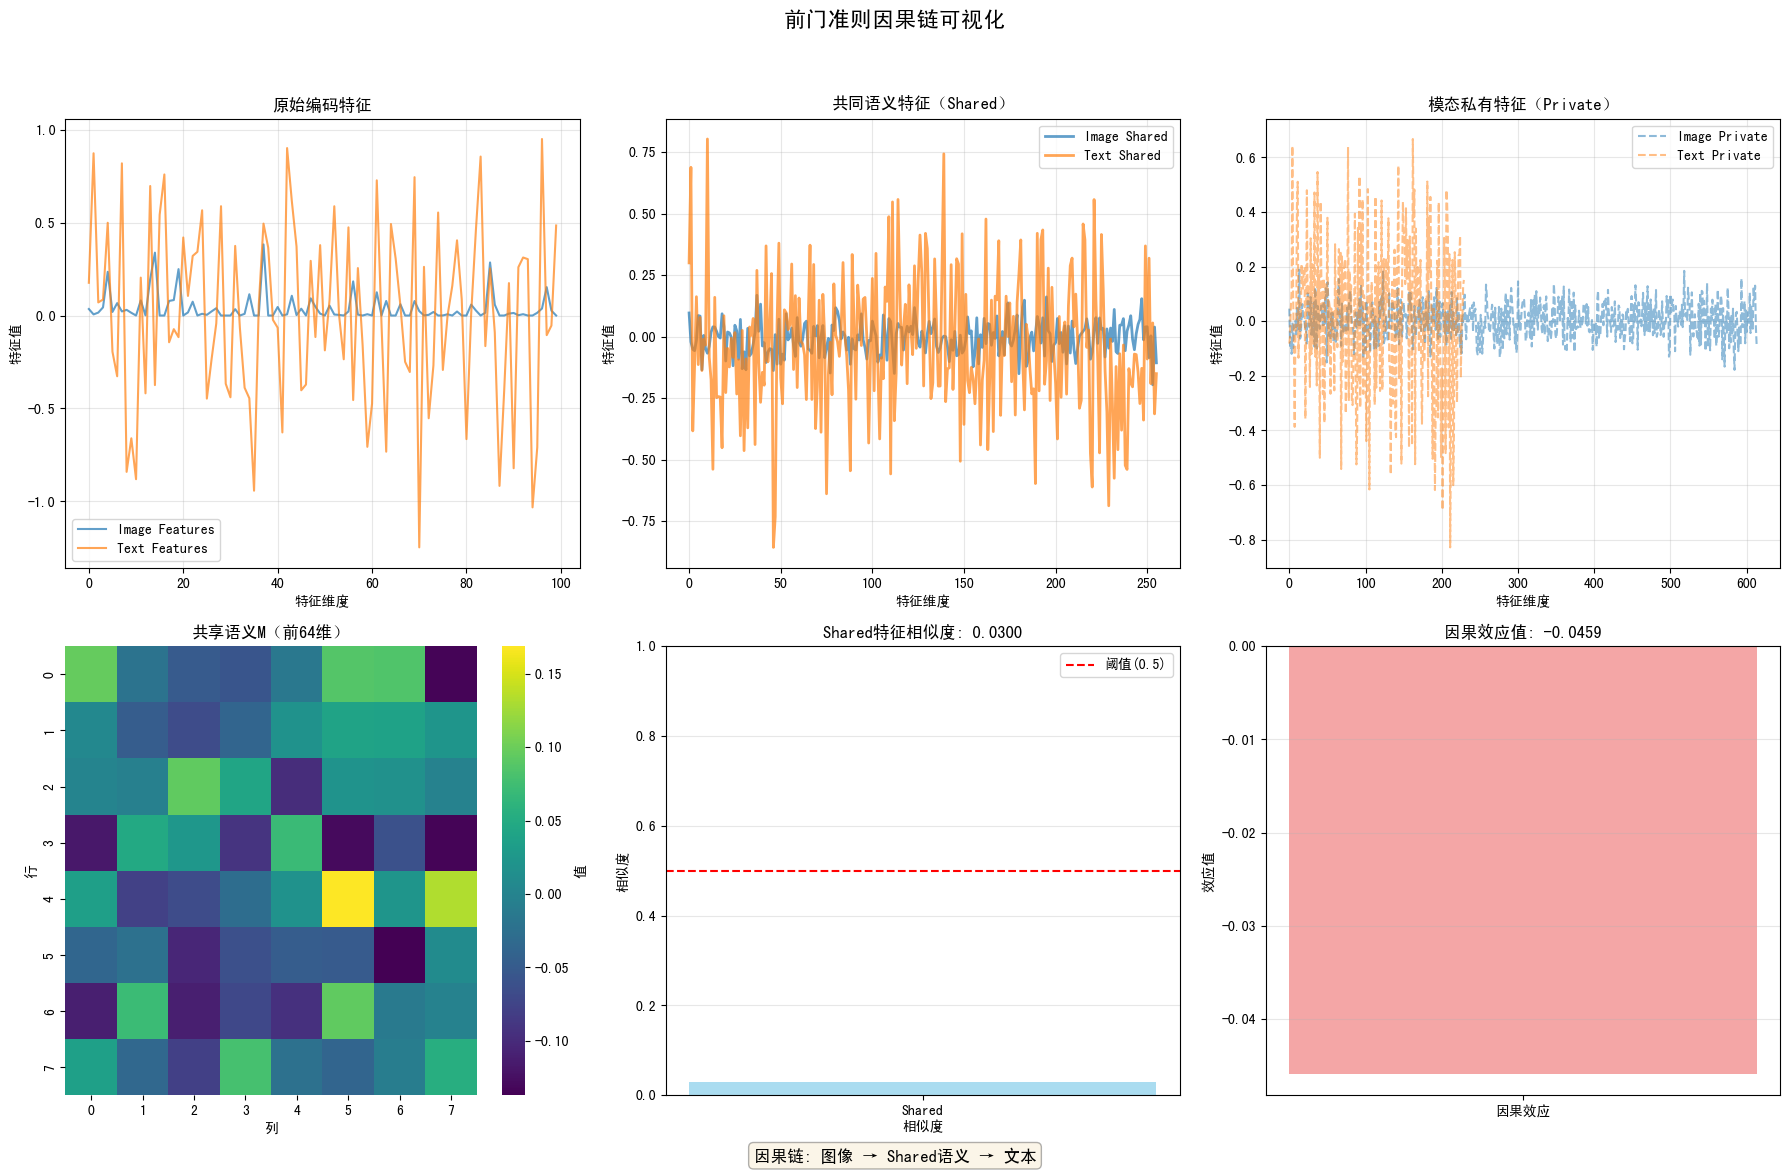

In [17]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置默认字体
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
# plt.rcParams['axes.unicode_minus'] = False
# visualize_causal_chain(image_features, text_features, features, shared_semantic, causal_effect)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('前门准则因果链可视化', fontsize=16, fontweight='bold')

# 1. 原始特征
ax = axes[0, 0]
img_feat = image_features[0].detach().numpy()[:100]
txt_feat = text_features[0].detach().numpy()[:100]
ax.plot(img_feat, label='Image Features', alpha=0.7)
ax.plot(txt_feat, label='Text Features', alpha=0.7)
ax.set_title('原始编码特征', fontweight='bold')
ax.set_xlabel('特征维度')
ax.set_ylabel('特征值')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Shared特征
ax = axes[0, 1]
img_shared = features['image_shared'][0].detach().numpy()
txt_shared = features['text_shared'][0].detach().numpy()
ax.plot(img_shared, label='Image Shared', alpha=0.7, linewidth=2)
ax.plot(txt_shared, label='Text Shared', alpha=0.7, linewidth=2)
ax.set_title('共同语义特征（Shared）', fontweight='bold')
ax.set_xlabel('特征维度')
ax.set_ylabel('特征值')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Private特征
ax = axes[0, 2]
img_private = features['image_private'][0].detach().numpy()
txt_private = features['text_private'][0].detach().numpy()
ax.plot(img_private, label='Image Private', alpha=0.5, linestyle='--')
ax.plot(txt_private, label='Text Private', alpha=0.5, linestyle='--')
ax.set_title('模态私有特征（Private）', fontweight='bold')
ax.set_xlabel('特征维度')
ax.set_ylabel('特征值')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. 共享语义热图
ax = axes[1, 0]
semantic_matrix = shared_semantic[0, :64].detach().numpy().reshape(8, 8)
sns.heatmap(semantic_matrix, cmap='viridis', ax=ax, cbar_kws={'label': '值'})
ax.set_title('共享语义M（前64维）', fontweight='bold')
ax.set_xlabel('列')
ax.set_ylabel('行')

# 5. Shared特征相似度
ax = axes[1, 1]
shared_sim = F.cosine_similarity(
    features['image_shared'],
    features['text_shared']
).item()
ax.bar(['Shared\n相似度'], [shared_sim], color='skyblue', alpha=0.7)
ax.axhline(y=0.5, color='red', linestyle='--', label='阈值(0.5)')
ax.set_title(f'Shared特征相似度: {shared_sim:.4f}', fontweight='bold')
ax.set_ylabel('相似度')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 6. 因果效应
ax = axes[1, 2]
effect_value = causal_effect.item()
ax.bar(['因果效应'], [effect_value], color='lightcoral', alpha=0.7)
ax.set_title(f'因果效应值: {effect_value:.4f}', fontweight='bold')
ax.set_ylabel('效应值')
ax.grid(True, alpha=0.3, axis='y')

# 添加说明
fig.text(0.5, 0.02, '因果链: 图像 → Shared语义 → 文本', ha='center',
        fontsize=12, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('causal_chain_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 图片检索

In [ ]:
_, valid_df = make_train_valid_dfs(test_size=0.2, random_state=42)

In [ ]:
config = CLIPConfig()
tokenizer = DistilBertTokenizer.from_pretrained(config.text_model_path)
valid_loader = build_loaders(valid_df, tokenizer, mode="valid")

model = CLIPModel().to(config.device)
model.load_state_dict(torch.load("./best_1.pt", map_location=config.device))
model.eval()
print_flag = True

print("提取图像嵌入...")
valid_image_embeddings = []
with torch.no_grad():
    for batch in tqdm(valid_loader, total=len(valid_loader)):
        if print_flag:
            print("图像输入形状:", batch["image"].shape)
            print_flag = False
        image_features = model.image_encoder(batch["image"].to(config.device))
        image_embeddings = model.image_projection(image_features)
        valid_image_embeddings.append(image_embeddings)

In [ ]:
query = 'Four men are sitting in red chairs'
config = CLIPConfig()
tokenizer = DistilBertTokenizer.from_pretrained(config.text_model_path)
encoded_query = tokenizer([query])

batch = {
    key: torch.tensor(values).to(config.device)
    for key, values in encoded_query.items()
}

# 编码文本查询
with torch.no_grad():
    text_features = model.text_encoder(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )
    text_embeddings = model.text_projection(text_features)

print(text_features.shape)
# 计算相似度
image_embeddings_n = F.normalize(torch.cat(valid_image_embeddings), p=2, dim=-1)
text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
dot_similarity = text_embeddings_n @ image_embeddings_n.T
print(dot_similarity.shape)
print(dot_similarity[:9])

image_filenames=valid_df['image_name'].values
n = 9
# 获取top-k匹配结果
similarities, indices = torch.topk(dot_similarity.squeeze(0), n * 5)
matches = [image_filenames[idx] for idx in indices[::5]]
similarities = similarities[::5].cpu().numpy()
print(matches)
print(similarities)

# 可视化结果
_, axes = plt.subplots(3, 3, figsize=(10, 10))
for match, ax in zip(matches, axes.flatten()):
    image = cv2.imread(f"{config.image_path}/{match}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 数据处理

In [ ]:
from common.dataset import get_transforms, BaseDataset

In [ ]:
single_dataset = BaseDataset(
    image_filenames=['2284231661.jpg'],
    captions=['Four men are sitting in red chairs'],
    ids=[0],
    tokenizer=tokenizer,
    transforms=get_transforms(mode="valid")
)

single_dataloader = torch.utils.data.DataLoader(
    single_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

In [ ]:
for batch in single_dataloader:
    print(batch['image'].shape)  # (1, 3, H, W)
    print(batch['caption'])
    break

In [ ]:
# img_embeddings = torch.cat(valid_image_embeddings)

# print(img_embeddings.shape)
transforms = get_transforms(mode="valid")

image = cv2.imread('../datasets/flickr30k/flickr30k_images/2284231661.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = transforms(image=image)['image']
image_emb = torch.tensor(image).permute(2, 0, 1).float()

print(image_emb.shape)
# image_embedding_2284231661 = model.image_encoder()

In [ ]:
image_features = model.image_encoder(batch['image'].to(config.device))
image_embeddings = model.image_projection(image_features)
print(image_features)

In [ ]:
query = 'Four men are sitting in red chairs'
config = CLIPConfig()
tokenizer = DistilBertTokenizer.from_pretrained(config.text_model_path)
encoded_query = tokenizer([query])

batch = {
    key: torch.tensor(values).to(config.device)
    for key, values in encoded_query.items()
}

# 编码文本查询
with torch.no_grad():
    text_features = model.text_encoder(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )
    text_embeddings = model.text_projection(text_features)

print(text_features.shape)
# 计算相似度
image_embeddings_n = F.normalize(image_embeddings, p=2, dim=-1)
text_embeddings_n = F.normalize(text_embeddings, p=2, dim=-1)
dot_similarity = text_embeddings_n @ image_embeddings_n.T
print(dot_similarity.shape)

# image_filenames=valid_df['image_name'].values
# n = 9
# # 获取top-k匹配结果
# _, indices = torch.topk(dot_similarity.squeeze(0), n * 5)
# matches = [image_filenames[idx] for idx in indices[::5]]
# print(matches)

# # 可视化结果
# _, axes = plt.subplots(3, 3, figsize=(10, 10))
# for match, ax in zip(matches, axes.flatten()):
#     image = cv2.imread(f"{config.image_path}/{match}")
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     ax.imshow(image)
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [ ]:
import pandas as pd

In [ ]:
dataframe = pd.read_csv('../datasets/flickr30k/captions.txt')

In [ ]:
dataframe

In [ ]:
single_dataset = BaseDataset(
    image_filenames=dataframe[:5]['image_name'].tolist(),
    captions=dataframe[:5]['comment'].tolist(),
    ids=dataframe[:5]['comment_number'].tolist(),
    tokenizer=tokenizer,
    transforms=get_transforms(mode="valid")
)

single_dataloader = torch.utils.data.DataLoader(
    single_dataset,
    batch_size=5,
    shuffle=False,
    num_workers=0
)

In [ ]:
def get_text_embedding(query):
    config = CLIPConfig()
    tokenizer = DistilBertTokenizer.from_pretrained(config.text_model_path)
    encoded_query = tokenizer([query])

    batch = {
        key: torch.tensor(values).to(config.device)
        for key, values in encoded_query.items()
    }

    # 编码文本查询
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        text_embeddings = model.text_projection(text_features)
    
    return text_features


In [ ]:
text_features = []

for i in range(5):
    query = dataframe['comment'][i]
    text_feat = get_text_embedding(query)
    text_features.append(text_feat)

In [ ]:
for batch in single_dataloader:
    print(batch['image'].shape)  # (1, 3, H, W)

# batch['image'][0].shape

image_features = model.image_encoder(batch['image'].to(config.device))
image_embeddings = model.image_projection(image_features)
print(image_features[0].shape)

In [ ]:
# 提取特征向量
text_feats = np.vstack([feat[0].cpu().detach().numpy() for feat in text_features])
# text_feat = text_features[0].cpu().detach().numpy()  # (768,)
image_feat = image_features[0].cpu().detach().numpy()  # (2048,)

print(f"Text features shape: {text_feats.shape}")  # 应该是 (5, 768)
print(f"Image feature shape: {image_feat.shape}")   # 应该是 (2048,)

# 将所有文本特征补零到2048维
text_feats_padded = np.pad(text_feats, ((0, 0), (0, 2048 - 768)), 'constant')  # (5, 2048)

# 组合所有特征：5个文本 + 1个图像
combined_features = np.vstack([text_feats_padded, image_feat.reshape(1, -1)])  # (6, 2048)

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
features_2d = pca.fit_transform(combined_features)  # (6, 2)

# 分离文本和图像的2D坐标
text_2d = features_2d[:5, :]  # 前5个点是文本特征
image_2d = features_2d[5:, :]  # 最后1个点是图像特征

# 可视化
plt.figure(figsize=(12, 10))

# 绘制5个文本特征点
plt.scatter(text_2d[:, 0], text_2d[:, 1], 
            c='blue', s=200, label='Text Features (5 captions)', 
            marker='o', edgecolors='black', linewidth=2, alpha=0.7)

# 为每个文本点添加编号
for i in range(5):
    plt.annotate(f'Text {i+1}', 
                (text_2d[i, 0], text_2d[i, 1]), 
                fontsize=10, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

# 绘制图像特征点
plt.scatter(image_2d[0, 0], image_2d[0, 1], 
            c='orange', s=300, label='Image Feature', 
            marker='s', edgecolors='black', linewidth=2, alpha=0.9)

plt.annotate('Image', 
            (image_2d[0, 0], image_2d[0, 1]), 
            fontsize=12, ha='center', va='bottom',
            xytext=(0, 5), textcoords='offset points', fontweight='bold')

# 添加从图像到各个文本特征的连接线
for i in range(5):
    plt.plot([image_2d[0, 0], text_2d[i, 0]], 
             [image_2d[0, 1], text_2d[i, 1]], 
             'r--', alpha=0.3, linewidth=1)
    
    # 计算每个距离
    dist = np.linalg.norm(image_2d[0] - text_2d[i])
    # 在连线中点添加距离标注
    mid_x = (image_2d[0, 0] + text_2d[i, 0]) / 2
    mid_y = (image_2d[0, 1] + text_2d[i, 1]) / 2
    plt.text(mid_x, mid_y, f'{dist:.3f}', 
            fontsize=8, ha='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# 计算平均距离
avg_distance = np.mean([np.linalg.norm(image_2d[0] - text_2d[i]) for i in range(5)])

plt.title(f'PCA Visualization: Image vs 5 Text Captions\nAverage Distance: {avg_distance:.4f}', 
          fontsize=14)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('pca_visualization.png',           # 文件名
            dpi=300,                           # 高分辨率
            bbox_inches='tight',               # 去除空白边缘
            facecolor='white',                 # 背景色
            edgecolor='none')                  # 无边框

plt.show()